# 💹 FinSight – Exploratory Data Analysis
**Indian Personal Finance & Spending Habits**

> This notebook performs end-to-end exploratory data analysis (EDA) on a dataset of
> 20 000 (or sample) individuals' income, expenses, and savings data.
> It feeds directly into the FinSight Streamlit dashboard (`app.py`).

---
### Pipeline
```
Raw CSV  →  Load & Validate  →  Feature Engineering  →  EDA  →  Insights  →  Dashboard
```

## 0 · Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Notebook aesthetics
plt.rcParams.update({
    'figure.facecolor': '#0D1117',
    'axes.facecolor':   '#161B22',
    'axes.edgecolor':   '#30363D',
    'axes.labelcolor':  '#E6EDF3',
    'axes.titlecolor':  '#E6EDF3',
    'xtick.color':      '#8B949E',
    'ytick.color':      '#8B949E',
    'text.color':       '#E6EDF3',
    'grid.color':       '#21262D',
    'font.family':      'DejaVu Sans',
    'figure.dpi':       120,
})
sns.set_theme(style='dark', palette='muted')

PALETTE = ['#00C9A7','#845EC2','#FF6F91','#FFC75F','#F9F871',
           '#00B8D9','#FF9671','#D65DB1','#4ECDC4','#A8E6CF','#FF8B94']
print('✅ Libraries loaded')

✅ Libraries loaded


## 1 · Load & Inspect Data
We load the CSV and immediately check shape, dtypes, and missing values.

In [2]:
df_raw = pd.read_csv('finance_data.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (500, 27)


,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,58931.19,60,2,Freelancer,Tier 1,15377.00,595.07,2647.57,6779.59,3123.30,...,13730.97,11443.28,864.93,702.76,688.80,426.98,263.32,308.58,517.64,190.27
1,35087.79,50,1,Salaried,Tier 3,9733.99,4403.42,1080.96,2499.42,1186.41,...,7157.91,6489.75,637.84,321.28,409.97,333.09,325.82,409.35,307.18,84.37
2,98456.03,36,1,Business Owner,Tier 1,25131.46,7593.20,3514.15,6124.04,4211.17,...,30816.74,21288.87,1589.24,1096.98,2221.26,719.60,340.19,290.19,759.58,948.80
3,56246.30,29,0,Salaried,Tier 1,13647.30,10532.31,3102.82,6757.34,5487.65,...,8830.67,2149.93,1402.72,594.17,949.72,521.61,824.60,321.10,0.00,342.16
4,64837.87,42,0,Freelancer,Tier 1,12768.57,7028.30,3533.29,3977.42,3888.51,...,10374.06,19353.88,644.09,683.51,1491.85,436.47,405.89,428.69,0.00,520.33


In [3]:
print('=== Data Types ===')
print(df_raw.dtypes)
print('\n=== Missing Values ===')
print(df_raw.isnull().sum())

=== Data Types ===
Income                             float64
Age                                  int64
Dependents                           int64
Occupation                             str
City_Tier                              str
Rent                               float64
Loan_Repayment                     float64
Insurance                          float64
Groceries                          float64
Transport                          float64
Eating_Out                         float64
Entertainment                      float64
Utilities                          float64
Healthcare                         float64
Education                          float64
Miscellaneous                      float64
Desired_Savings_Percentage         float64
Desired_Savings                    float64
Disposable_Income                  float64
Potential_Savings_Groceries        float64
Potential_Savings_Transport        float64
Potential_Savings_Eating_Out       float64
Potential_Savings_Entertainment    

In [4]:
df_raw.describe().T.style.background_gradient(cmap='Greens')

,count,mean,std,min,25%,50%,75%,max
Income,500.000000,57755.356600,21538.137132,0.000000,42480.212500,57904.145000,72402.335000,123819.710000
Age,500.000000,42.436000,11.656142,22.000000,33.000000,44.000000,53.000000,61.000000
Dependents,500.000000,1.472000,1.124163,0.000000,1.000000,1.000000,2.000000,4.000000
Rent,500.000000,14650.196980,6538.948707,0.000000,9805.900000,13977.995000,19111.187500,36783.040000
Loan_Repayment,500.000000,6011.770160,4119.593391,0.000000,2793.572500,5528.070000,8665.747500,18228.910000
Insurance,500.000000,1989.246480,1187.867777,0.000000,1099.942500,1739.470000,2650.210000,5768.180000
Groceries,500.000000,5655.594140,2738.531829,0.000000,3539.342500,5190.195000,7335.590000,15036.840000
Transport,500.000000,3770.818840,1874.215237,0.000000,2440.547500,3459.775000,4937.772500,10462.580000
Eating_Out,500.000000,3952.029980,2321.417927,0.000000,2095.797500,3441.720000,5501.567500,11629.440000
Entertainment,500.000000,2536.228040,1569.597910,0.000000,1285.367500,2148.215000,3559.792500,7767.880000


## 2 · Data Cleaning & Feature Engineering
- Convert numeric columns
- Compute **Total_Expenses**, **Savings_Rate_%**, **Expense_to_Income_%**
- Compute **Savings_Gap** = Desired − Actual

In [5]:
EXPENSE_COLS = [
    'Rent','Loan_Repayment','Insurance','Groceries','Transport',
    'Eating_Out','Entertainment','Utilities','Healthcare',
    'Education','Miscellaneous'
]

df = df_raw.copy()
df.dropna(how='all', inplace=True)

# Coerce numerics
for col in EXPENSE_COLS + ['Income','Disposable_Income','Desired_Savings']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Derived features
df['Total_Expenses']     = df[EXPENSE_COLS].sum(axis=1)
df['Savings_Rate_%']     = ((df['Income'] - df['Total_Expenses']) / df['Income'].replace(0,np.nan) * 100).round(1)
df['Expense_to_Income_%']= (df['Total_Expenses'] / df['Income'].replace(0,np.nan) * 100).round(1)
df['Actual_Savings']     = (df['Income'] - df['Total_Expenses']).clip(lower=0)
df['Savings_Gap']        = (df['Desired_Savings'] - df['Actual_Savings']).round(2)

print(f'Cleaned shape: {df.shape}')
df[['Income','Total_Expenses','Savings_Rate_%','Savings_Gap']].describe().round(2)

Cleaned shape: (500, 32)


,Income,Total_Expenses,Savings_Rate_%,Savings_Gap
count,500.00,500.00,498.00,500.00
mean,57755.36,47590.40,17.67,2754.42
std,21538.14,18870.78,10.29,7752.64
min,0.00,0.00,-7.90,-25921.87
25%,42480.21,34625.69,10.22,-1782.70
50%,57904.14,46950.05,17.65,2289.16
75%,72402.33,59975.40,24.62,6990.17
max,123819.71,103481.42,47.20,28275.60


## 3 · Category-Wise Spending Analysis

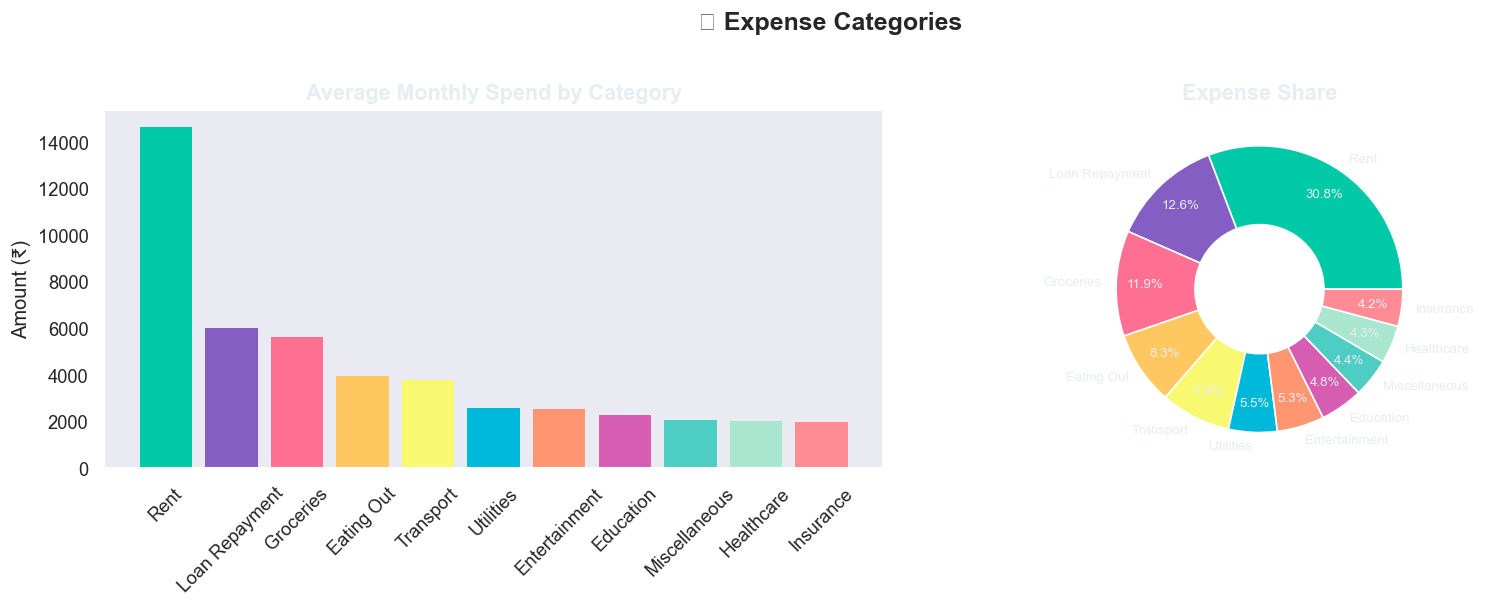

In [6]:
cat_means = df[EXPENSE_COLS].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(
    [c.replace('_',' ') for c in cat_means.index],
    cat_means.values, color=PALETTE[:len(cat_means)], edgecolor='none'
)
axes[0].set_title('Average Monthly Spend by Category', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Amount (₹)')
axes[0].tick_params(axis='x', rotation=45)
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f'₹{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8, color='#E6EDF3')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    cat_means.values,
    labels=[c.replace('_',' ') for c in cat_means.index],
    colors=PALETTE[:len(cat_means)],
    autopct='%1.1f%%', pctdistance=0.8,
    wedgeprops=dict(width=0.55)
)
for t in texts+autotexts:
    t.set_color('#E6EDF3'); t.set_fontsize(8)
axes[1].set_title('Expense Share', fontsize=13, fontweight='bold')

plt.suptitle('💸 Expense Categories', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4 · Income Distribution by City Tier & Occupation

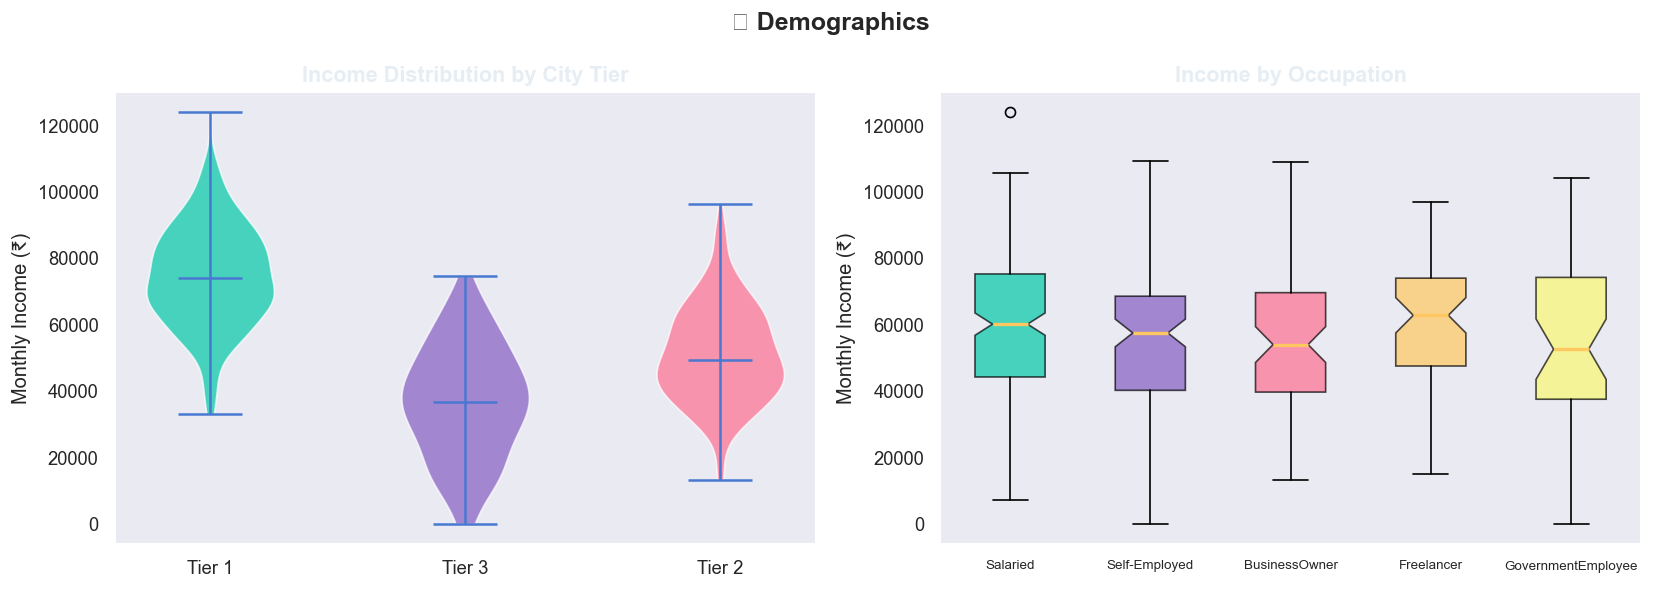

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin – Income by City Tier
tiers = df['City_Tier'].unique()
data_by_tier = [df[df['City_Tier']==t]['Income'].values for t in tiers]
vp = axes[0].violinplot(data_by_tier, showmedians=True)
for i,(body,c) in enumerate(zip(vp['bodies'],PALETTE)):
    body.set_facecolor(c); body.set_alpha(0.7)
axes[0].set_xticks(range(1,len(tiers)+1))
axes[0].set_xticklabels(tiers)
axes[0].set_title('Income Distribution by City Tier', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Monthly Income (₹)')

# Boxplot – Income by Occupation
occs   = df['Occupation'].value_counts().index.tolist()
bp_data= [df[df['Occupation']==o]['Income'].values for o in occs]
bp = axes[1].boxplot(bp_data, patch_artist=True, notch=True,
                     medianprops=dict(color='#FFC75F',linewidth=2))
for patch,c in zip(bp['boxes'],PALETTE):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_xticks(range(1,len(occs)+1))
axes[1].set_xticklabels([o.replace(' ','') for o in occs], fontsize=8)
axes[1].set_title('Income by Occupation', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Monthly Income (₹)')

plt.suptitle('👤 Demographics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 5 · Savings Rate Analysis

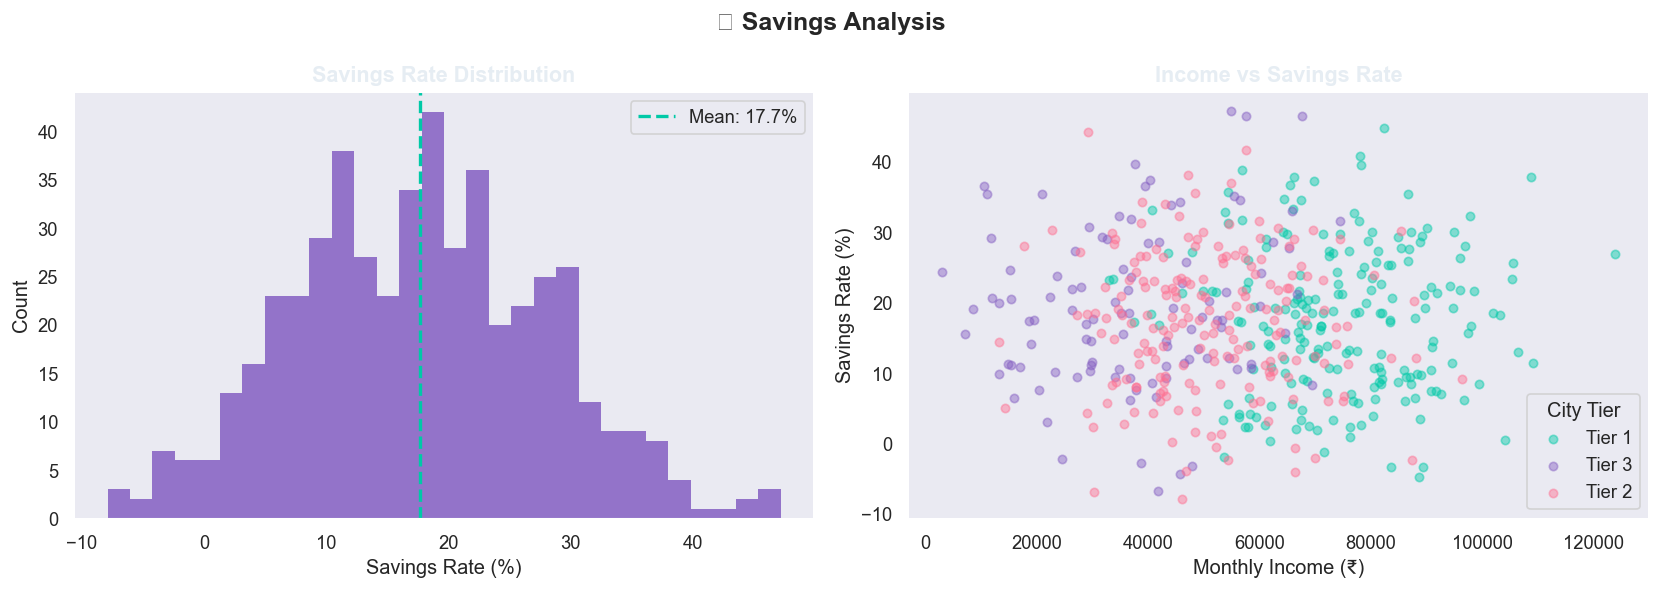

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of Savings Rate
axes[0].hist(df['Savings_Rate_%'].dropna(), bins=30, color='#845EC2', alpha=0.85, edgecolor='none')
axes[0].axvline(df['Savings_Rate_%'].mean(), color='#00C9A7', linewidth=2, linestyle='--',
                label=f'Mean: {df["Savings_Rate_%"].mean():.1f}%')
axes[0].set_title('Savings Rate Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Savings Rate (%)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Scatter – Income vs Savings Rate (coloured by City Tier)
for i, tier in enumerate(df['City_Tier'].unique()):
    mask = df['City_Tier'] == tier
    axes[1].scatter(df.loc[mask,'Income'], df.loc[mask,'Savings_Rate_%'],
                    alpha=0.45, s=25, color=PALETTE[i], label=tier)
axes[1].set_title('Income vs Savings Rate', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Monthly Income (₹)')
axes[1].set_ylabel('Savings Rate (%)')
axes[1].legend(title='City Tier')

plt.suptitle('📈 Savings Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 6 · Age Group Breakdown

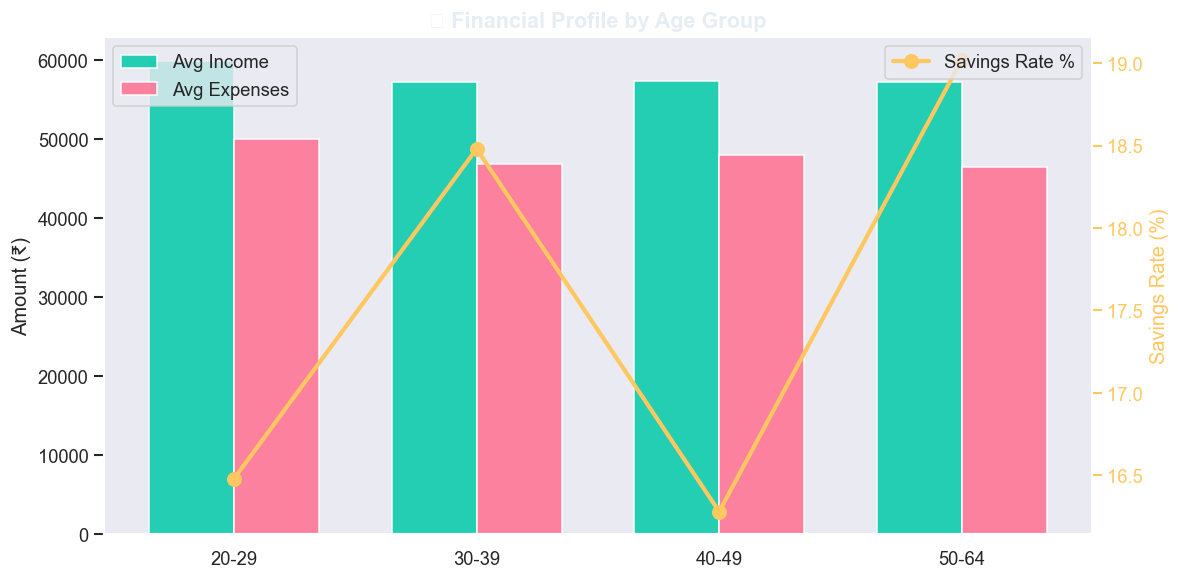

Age_Group  Avg_Income  Avg_Expenses  Avg_Savings  Count
    20-29    59854.46      49942.07        16.48     97
    30-39    57196.68      46789.60        18.48    102
    40-49    57368.47      47972.15        16.28    136
    50-64    57185.59      46388.27        19.02    165


In [10]:
bins   = [20,30,40,50,65]
labels = ['20-29','30-39','40-49','50-64']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

age_grp = df.groupby('Age_Group', observed=True).agg(
    Avg_Income=('Income','mean'),
    Avg_Expenses=('Total_Expenses','mean'),
    Avg_Savings=('Savings_Rate_%','mean'),
    Count=('Income','count')
).round(2).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
x = np.arange(len(age_grp))
w = 0.35
ax1.bar(x-w/2, age_grp['Avg_Income'],   w, color='#00C9A7', label='Avg Income',   alpha=0.85)
ax1.bar(x+w/2, age_grp['Avg_Expenses'], w, color='#FF6F91', label='Avg Expenses', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(age_grp['Age_Group'])
ax1.set_ylabel('Amount (₹)')
ax1.set_title('📅 Financial Profile by Age Group', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(x, age_grp['Avg_Savings'], color='#FFC75F', linewidth=2.5,
         marker='o', markersize=8, label='Savings Rate %')
ax2.set_ylabel('Savings Rate (%)', color='#FFC75F')
ax2.tick_params(axis='y', colors='#FFC75F')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()
print(age_grp.to_string(index=False))

## 7 · Correlation Heatmap (Expense Categories)

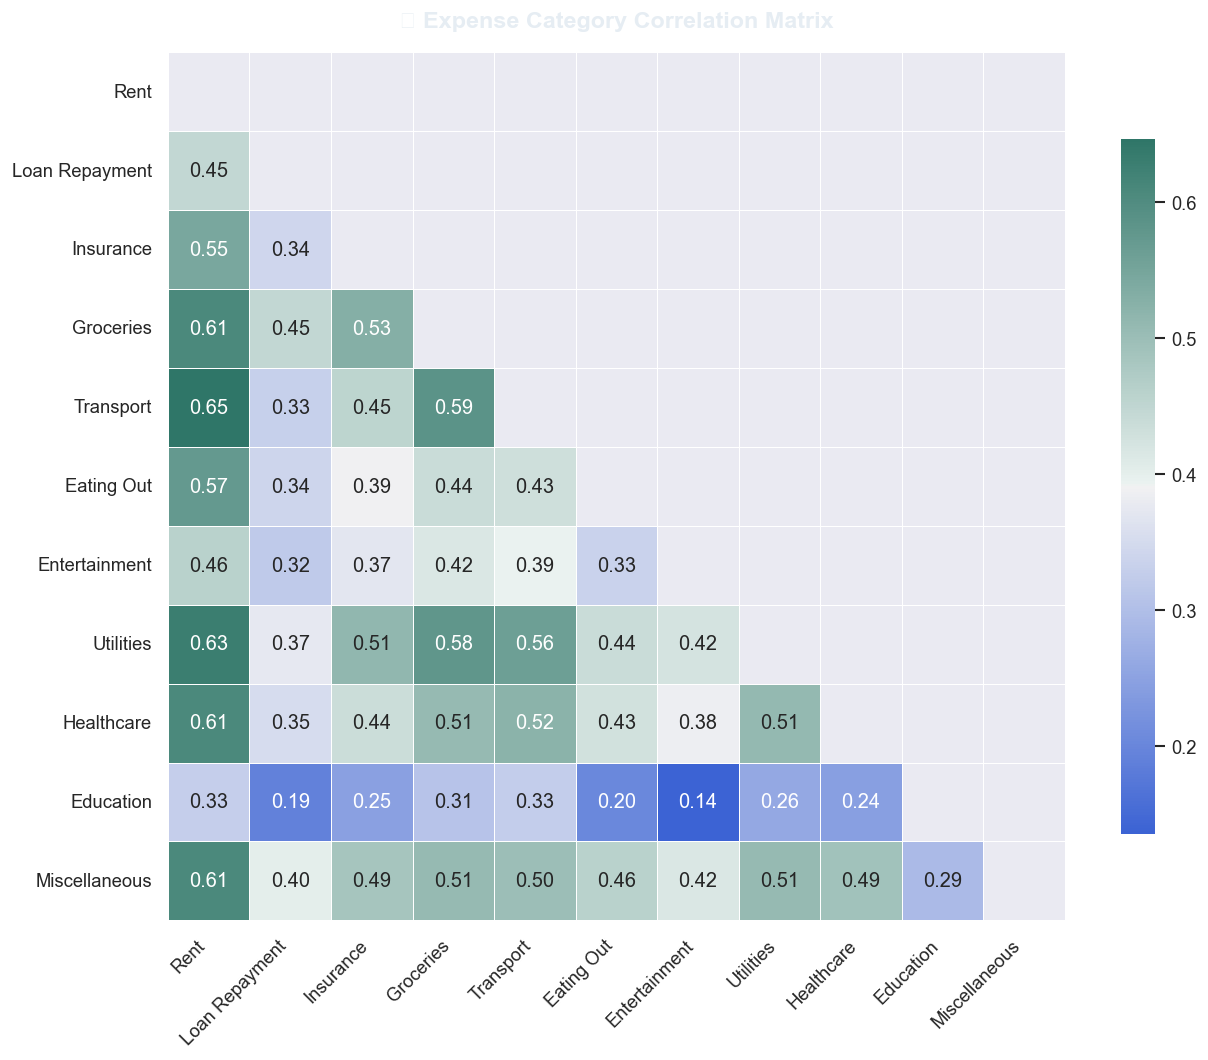

In [11]:
corr = df[EXPENSE_COLS].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', linewidths=0.5,
    cmap=sns.diverging_palette(260, 170, s=80, l=45, as_cmap=True),
    ax=ax, cbar_kws={'shrink':0.8},
    xticklabels=[c.replace('_',' ') for c in corr.columns],
    yticklabels=[c.replace('_',' ') for c in corr.index]
)
ax.set_title('🔥 Expense Category Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8 · Potential Savings Opportunity

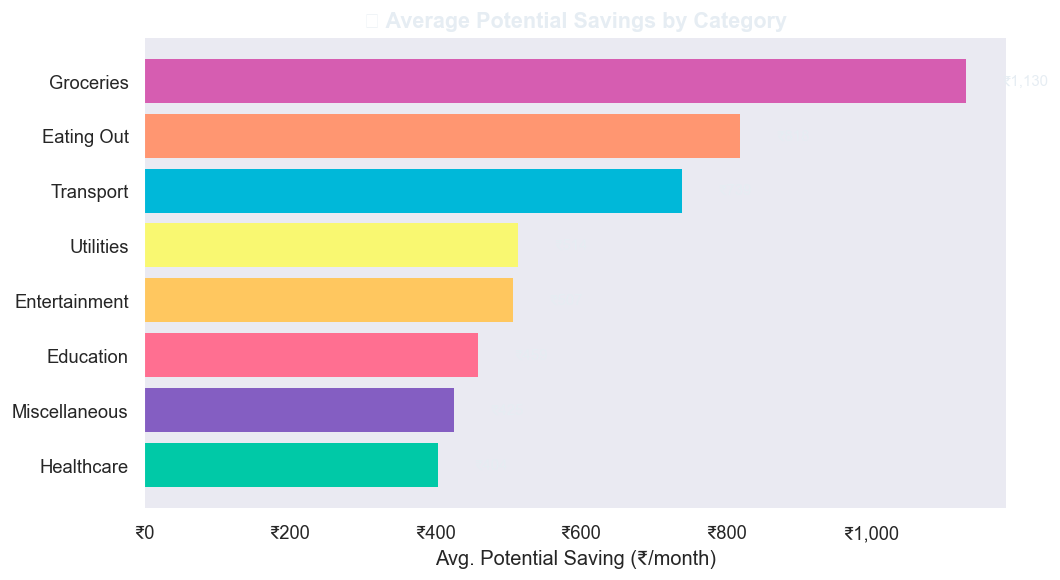

In [12]:
PS_COLS = [c for c in df.columns if c.startswith('Potential_Savings_')]
ps_means = df[PS_COLS].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    [c.replace('Potential_Savings_','').replace('_',' ') for c in ps_means.index],
    ps_means.values,
    color=PALETTE[:len(ps_means)], edgecolor='none'
)
for bar in bars:
    ax.text(bar.get_width()+50, bar.get_y()+bar.get_height()/2,
            f'₹{bar.get_width():,.0f}', va='center', fontsize=9, color='#E6EDF3')
ax.set_title('💡 Average Potential Savings by Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Avg. Potential Saving (₹/month)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v:,.0f}'))
plt.tight_layout()
plt.show()

## 9 · Summary & Key Takeaways

In [13]:
print('=' * 60)
print('         📊 FINSIGHT EDA SUMMARY')
print('=' * 60)
print(f'  Total individuals analysed   : {len(df):,}')
print(f'  Average monthly income       : ₹{df["Income"].mean():,.0f}')
print(f'  Average total expenses       : ₹{df["Total_Expenses"].mean():,.0f}')
print(f'  Average savings rate         : {df["Savings_Rate_%"].mean():.1f}%')
print(f'  Top expense category         : {df[EXPENSE_COLS].mean().idxmax().replace("_"," ")}')
print(f'  City tier most represented   : {df["City_Tier"].value_counts().idxmax()}')
print(f'  % meeting savings goal       : {(df["Savings_Gap"]<=0).mean()*100:.1f}%')
if PS_COLS:
    print(f'  Biggest savings opportunity  : {df[PS_COLS].mean().idxmax().replace("Potential_Savings_","").replace("_"," ")}')
print('=' * 60)
print()
print('→ Launch the interactive dashboard:  streamlit run app.py')

         📊 FINSIGHT EDA SUMMARY
  Total individuals analysed   : 500
  Average monthly income       : ₹57,755
  Average total expenses       : ₹47,590
  Average savings rate         : 17.7%
  Top expense category         : Rent
  City tier most represented   : Tier 1
  % meeting savings goal       : 36.0%
  Biggest savings opportunity  : Groceries

→ Launch the interactive dashboard:  streamlit run app.py
